In [1]:
import os
import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../")))
from srlib.dataset.loading import load_srcnn_dataset
from srlib.dataset.visualization import plot_patch_pairs
from srlib.deep_learning.srcnn import SRCNNModel
from srlib.constants import (
    CLASS_LABELS_PATH,
    HR_ROOT,
    LR_ROOT,
    SRCNN_PATCH_SIZE,
    SRCNN_STRIDE,
)

In [ ]:
# X -> Low-resolution patches (model input), upscaled to the HR frame size
# Y -> High-resolution patches (target)
# The LR side uses SRCNN_UPSCALE_INTERPOLATION, the same value
# super_resolve_image uses at inference time. No per-image degradation kernel
# is read: it does not exist for a real low-resolution capture.
X_train, Y_train, X_val, Y_val, X_test, Y_test, hr_h, hr_w = load_srcnn_dataset(
    HR_ROOT,
    LR_ROOT,
    CLASS_LABELS_PATH,
    patch_size=SRCNN_PATCH_SIZE,
    stride=SRCNN_STRIDE,
)


 SRCNN dataset | patch 48, stride 24
  images    360 indexed -> 180 kept -> 145 train / 17 val / 18 test


  patches   52,345 train / 6,137 val / 6,498 test   of 48 x 48 x 3
  memory    1.67 GB of inputs
  frame     478 x 478
  done in 2.9s

X_train shape: (52345, 48, 48, 3), Y_train shape: (52345, 48, 48, 3)
X_val shape: (6137, 48, 48, 3), Y_val shape: (6137, 48, 48, 3)
X_test shape: (6498, 48, 48, 3), Y_test shape: (6498, 48, 48, 3)


X_train range: [0.0000, 1.0000]
Y_train range: [0.0000, 1.0000]
NaN in X_train: False, NaN in Y_train: False


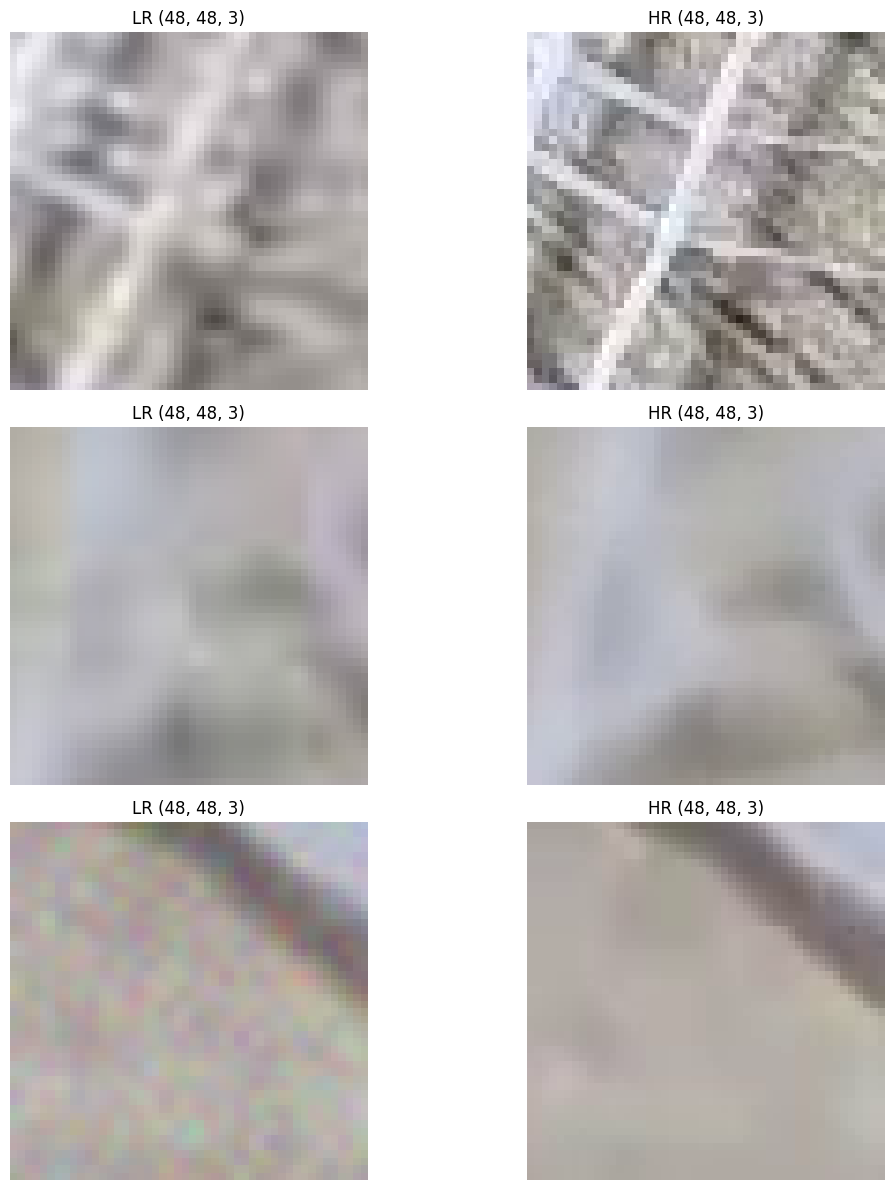

In [3]:
# What the model is actually fed: input on the left, its target on the right.
_ = plot_patch_pairs(X_train, Y_train, count=3, seed=0)

In [4]:
model = SRCNNModel()

model.setup_model(input_shape=X_train.shape[1:], learning_rate=1e-4)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 48, 48, 96)        23424     
                                                                 
 conv2d_1 (Conv2D)           (None, 48, 48, 32)        3104      
                                                                 
 conv2d_2 (Conv2D)           (None, 48, 48, 3)         2403      
                                                                 
Total params: 28,931
Trainable params: 28,931
Non-trainable params: 0
_________________________________________________________________


In [6]:
# Train SRCNN and capture callbacks for metrics
history, time_cb, mem_cb = model.fit(
    X_train, Y_train, X_val, Y_val,
    batch_size=32,
    epochs=50
)

Training on GPU: /physical_device:GPU:0
Epoch 1/50
8436/8436 [==============================] - 41s 4ms/step - loss: 0.0034 - psnr: 28.8328 - ssim: 0.7958 - val_loss: 0.0017 - val_psnr: 29.8603 - val_ssim: 0.8153 - lr: 1.0000e-04 - epoch_time_sec: 41.2931 - gpu_mean_current_mb: 3756.6384 - gpu_peak_mb: 3999.7483
Epoch 2/50
8436/8436 [==============================] - 36s 4ms/step - loss: 0.0017 - psnr: 30.0034 - ssim: 0.8149 - val_loss: 0.0016 - val_psnr: 30.2063 - val_ssim: 0.8159 - lr: 1.0000e-04 - epoch_time_sec: 35.8333 - gpu_mean_current_mb: 3954.4875 - gpu_peak_mb: 3999.7483
Epoch 3/50
8436/8436 [==============================] - ETA: 0s - loss: 0.0017 - psnr: 30.0871 - ssim: 0.8163
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
8436/8436 [==============================] - 36s 4ms/step - loss: 0.0017 - psnr: 30.0871 - ssim: 0.8163 - val_loss: 0.0016 - val_psnr: 30.1913 - val_ssim: 0.8185 - lr: 1.0000e-04 - epoch_time_sec: 36.2826 - gpu_mean_current_mb

In [7]:
# Evaluates the run, saves the checkpoint, the HR frame size and the metrics
# under one timestamp, so the reporting notebooks resolve a single run.
timestamp, run_dir, metrics = model.evaluate_and_save(
    X_test, Y_test, history, time_cb, mem_cb, hr_h, hr_w,
)

1042/1042 [==============================] - 5s 5ms/step - loss: 0.0016 - psnr: 30.3599 - ssim: 0.8222
Loss: 0.0016, PSNR: 30.36 dB, SSIM: 0.8222
